In [95]:
import numpy as np
from filterpy.kalman import ExtendedKalmanFilter
import jax
import joblib
from matplotlib import pyplot as plt

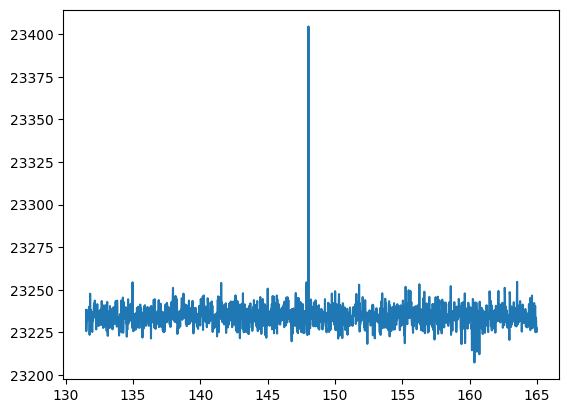

In [112]:
light_cureve_dict = joblib.load("subset_q1.joblib")

#vals is flux
#time (day), flux, possible error recorded by error
t, vals, err = light_cureve_dict[5097470][:3]
#100 stars

#set nan_values to be the average of its neighbors
nan_indices = np.argwhere(np.isnan(vals))
for nan_index in nan_indices:
    vals[nan_index] = (vals[nan_index - 1] + vals[nan_index + 1]) / 2

plt.plot(t, vals)


In [97]:
'''
mu is the expected value of the flux of a given star
d id the desired transit depth --> koi_depth†, Transit Depth (parts per million)
k is the frequency
a is orbital distance
'''

def h(theta):
    #mu is the expected value of flux
    mu = np.mean(vals)
    del_thet = 0.0093
    transit_d = 0.000084
    k = 13690
    m = 250000
    #mu is average of the flux for this
    result = mu * (1 - transit_d + 2*(transit_d/jax.numpy.pi))*jax.numpy.abs(1/jax.numpy.tan(k*jax.numpy.sin(theta)))
    return result.reshape()


h_der = jax.grad(h)


In [ ]:
#theta
G = 6.67e-11
dt = 0.01

#assume mass and radius similar to earth
m = 250000
r = 6371 #TO DO: fix radius

dim_x = 1
dim_z = 1

ekf = ExtendedKalmanFilter(dim_x, dim_z)

#initial state
#remember x is just theta
ekf.x = np.array([[0.0]])
ekf.P = np.array([[1.0]])

#Linear State
ekf.F = np.array([[1.0]])
ekf.B = np.array([[1.0]])
U = np.array([dt * np.sqrt((G * m)/r**3)])

#Noise
ekf.Q = np.array([[1e-10]])
ekf.R = np.array([[20/10**6]])
#ekf.R = np.array([[x*20/10**6]])

fluxes = []
for i, flux in enumerate(vals):
    ekf.predict(u=U)
    ekf.update(z=flux, HJacobian=h_der, Hx=h)
    fluxes.append(ekf.x.ravel())



[array([5.31278667e-05]), array([4.6367976e-05]), array([4.90689924e-05]), array([4.79395895e-05]), array([4.84158225e-05]), array([4.82044263e-05]), array([4.82950793e-05]), array([4.82627771e-05]), array([4.82709721e-05]), array([4.82616001e-05]), array([4.82674397e-05]), array([4.82581445e-05]), array([4.82804594e-05]), array([4.82986809e-05]), array([4.8271971e-05]), array([4.82352209e-05]), array([4.82964329e-05]), array([4.82614364e-05]), array([4.82660372e-05]), array([4.82916778e-05]), array([4.82564237e-05]), array([4.82844859e-05]), array([4.82910779e-05]), array([4.82897291e-05]), array([4.82695011e-05]), array([4.8280655e-05]), array([4.82672913e-05]), array([4.82712802e-05]), array([4.82594882e-05]), array([4.82560933e-05]), array([4.8262093e-05]), array([4.82775837e-05]), array([4.82440924e-05]), array([4.82671672e-05]), array([4.82637562e-05]), array([4.82714463e-05]), array([4.82837103e-05]), array([4.82884477e-05]), array([4.82781795e-05]), array([4.8268772e-05]), arra

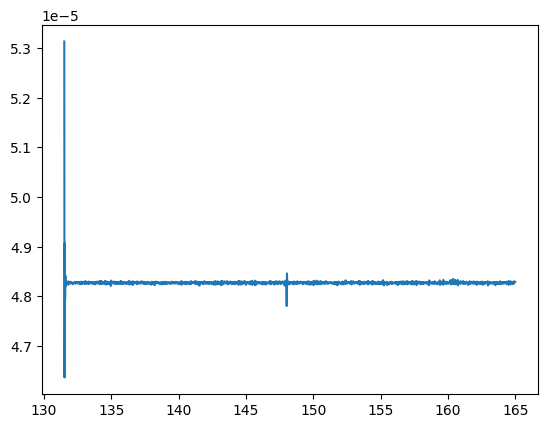

In [ ]:
#plot the observed measurements and then our thetas turned into brightness via H
plt.plot(t, fluxes)